In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

df = pd.read_csv('../data/raw/train_u6lujuX_CVtuZ9i.csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [9]:
print(df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum())
print(df['Loan_Status'].value_counts())

(614, 13)
<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 83.4 KB
None
       ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
count       614.000000         614.00

In [10]:
for col in ['Gender', 'Married', 'Dependents', 'Self_Employed']:
    df[col] = df[col].fillna(df[col].mode()[0])

In [11]:
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())

In [12]:
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median())

In [13]:
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

In [14]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [ ]:
import numpy as np

# 1. Total household income
df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']

# 2. Loan-to-Income ratio
df['LoanAmount_to_Income'] = df['LoanAmount'] / df['TotalIncome']

# 3. EMI (rough monthly installment)
df['EMI'] = df['LoanAmount'] / df['Loan_Amount_Term']

# 4. Balance income after EMI
df['BalanceIncome'] = (df['TotalIncome'] / 12) - df['EMI']

# 5. Log-transform skewed numeric columns
df['ApplicantIncome_log'] = np.log1p(df['ApplicantIncome'])
df['TotalIncome_log'] = np.log1p(df['TotalIncome'])
df['LoanAmount_log'] = np.log1p(df['LoanAmount'])

df[['TotalIncome', 'LoanAmount_to_Income', 'EMI', 'BalanceIncome', 'TotalIncome_log']].head()

,TotalIncome,LoanAmount_to_Income,EMI,BalanceIncome,TotalIncome_log
0,5849.0,0.021884,0.355556,487.061111,8.674197
1,6091.0,0.021015,0.355556,507.227778,8.714732
2,3000.0,0.022000,0.183333,249.816667,8.006701
3,4941.0,0.024287,0.333333,411.416667,8.505525
4,6000.0,0.023500,0.391667,499.608333,8.699681


In [16]:
# Binary categorical columns -> map to 0/1
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
df['Married'] = df['Married'].map({'Yes': 1, 'No': 0})
df['Education'] = df['Education'].map({'Graduate': 1, 'Not Graduate': 0})
df['Self_Employed'] = df['Self_Employed'].map({'Yes': 1, 'No': 0})

# Dependents has a '3+' category - clean it to numeric
df['Dependents'] = df['Dependents'].replace('3+', '3').astype(int)

# Target variable -> 1 = Approved (Y), 0 = Not Approved (N)
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})

# Property_Area -> One-Hot Encoding (multi-category, no order)
df = pd.get_dummies(df, columns=['Property_Area'], drop_first=True)

# Check the result
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,TotalIncome,LoanAmount_to_Income,EMI,BalanceIncome,ApplicantIncome_log,TotalIncome_log,LoanAmount_log,Property_Area_Semiurban,Property_Area_Urban
0,LP001002,1,0,0,1,0,5849,0.0,128.0,360.0,1.0,1,5849.0,0.021884,0.355556,487.061111,8.674197,8.674197,4.859812,False,True
1,LP001003,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,6091.0,0.021015,0.355556,507.227778,8.430327,8.714732,4.859812,False,False
2,LP001005,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,1,3000.0,0.022000,0.183333,249.816667,8.006701,8.006701,4.204693,False,True
3,LP001006,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,1,4941.0,0.024287,0.333333,411.416667,7.857094,8.505525,4.795791,False,True
4,LP001008,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,1,6000.0,0.023500,0.391667,499.608333,8.699681,8.699681,4.955827,False,True


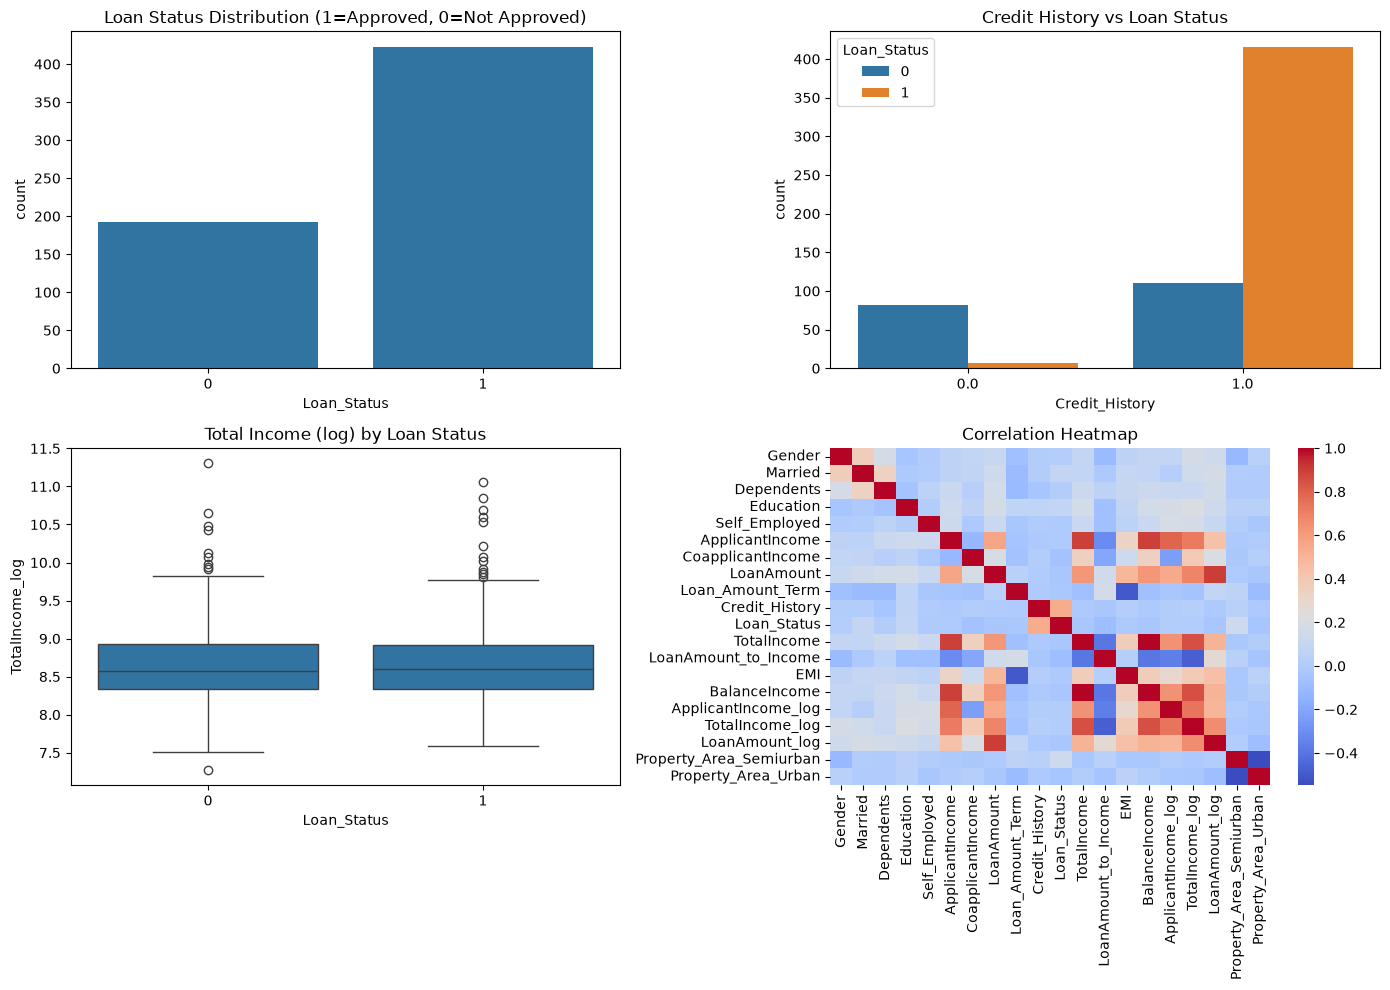

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Target class balance
sns.countplot(x='Loan_Status', data=df, ax=axes[0,0])
axes[0,0].set_title('Loan Status Distribution (1=Approved, 0=Not Approved)')

# 2. Credit History vs Loan Status
sns.countplot(x='Credit_History', hue='Loan_Status', data=df, ax=axes[0,1])
axes[0,1].set_title('Credit History vs Loan Status')

# 3. Total Income distribution by Loan Status
sns.boxplot(x='Loan_Status', y='TotalIncome_log', data=df, ax=axes[1,0])
axes[1,0].set_title('Total Income (log) by Loan Status')

# 4. Correlation heatmap
corr = df.drop(columns=['Loan_ID']).corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', ax=axes[1,1])
axes[1,1].set_title('Correlation Heatmap')

plt.tight_layout()
plt.savefig('../outputs/eda_overview.png', dpi=150)
plt.show()

In [18]:
from sklearn.model_selection import train_test_split

# Drop ID column (not predictive), separate features and target
X = df.drop(columns=['Loan_ID', 'Loan_Status'])
y = df['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))

(491, 19) (123, 19)
Loan_Status
1    0.686354
0    0.313646
Name: proportion, dtype: float64


In [19]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(y_train_res.value_counts())

Loan_Status
1    337
0    337
Name: count, dtype: int64


In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train_res)

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train_res, y_train_res)

xgb = XGBClassifier(eval_metric='logloss', random_state=42)
xgb.fit(X_train_res, y_train_res)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [22]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score

def evaluate(model, X_test_input, name):
    preds = model.predict(X_test_input)
    probs = model.predict_proba(X_test_input)[:, 1]
    print(f"--- {name} ---")
    print(classification_report(y_test, preds))
    print("ROC-AUC:", roc_auc_score(y_test, probs))
    print("F1:", f1_score(y_test, preds))
    print(confusion_matrix(y_test, preds))
    print()

evaluate(log_reg, X_test_scaled, "Logistic Regression")
evaluate(rf, X_test, "Random Forest")
evaluate(xgb, X_test, "XGBoost")

--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.71      0.63      0.67        38
           1       0.84      0.88      0.86        85

    accuracy                           0.80       123
   macro avg       0.77      0.76      0.76       123
weighted avg       0.80      0.80      0.80       123

ROC-AUC: 0.8297213622291022
F1: 0.8620689655172413
[[24 14]
 [10 75]]

--- Random Forest ---
              precision    recall  f1-score   support

           0       0.76      0.74      0.75        38
           1       0.88      0.89      0.89        85

    accuracy                           0.85       123
   macro avg       0.82      0.82      0.82       123
weighted avg       0.84      0.85      0.84       123

ROC-AUC: 0.8512383900928793
F1: 0.8888888888888888
[[28 10]
 [ 9 76]]

--- XGBoost ---
              precision    recall  f1-score   support

           0       0.69      0.71      0.70        38
           1       0.87      

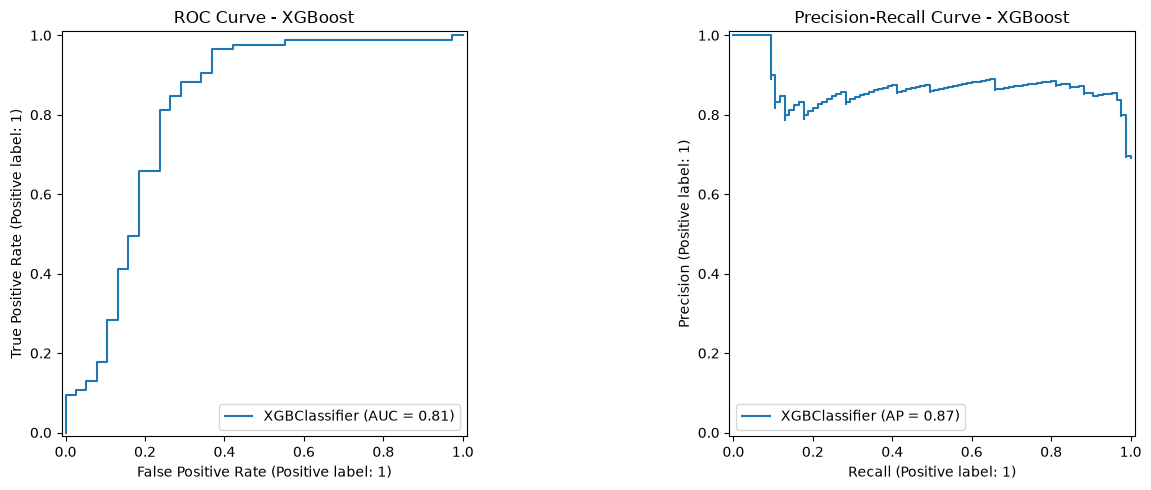

In [23]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
RocCurveDisplay.from_estimator(xgb, X_test, y_test, ax=axes[0])
axes[0].set_title('ROC Curve - XGBoost')

PrecisionRecallDisplay.from_estimator(xgb, X_test, y_test, ax=axes[1])
axes[1].set_title('Precision-Recall Curve - XGBoost')

plt.tight_layout()
plt.savefig('../outputs/roc_pr_curves.png', dpi=150)
plt.show()

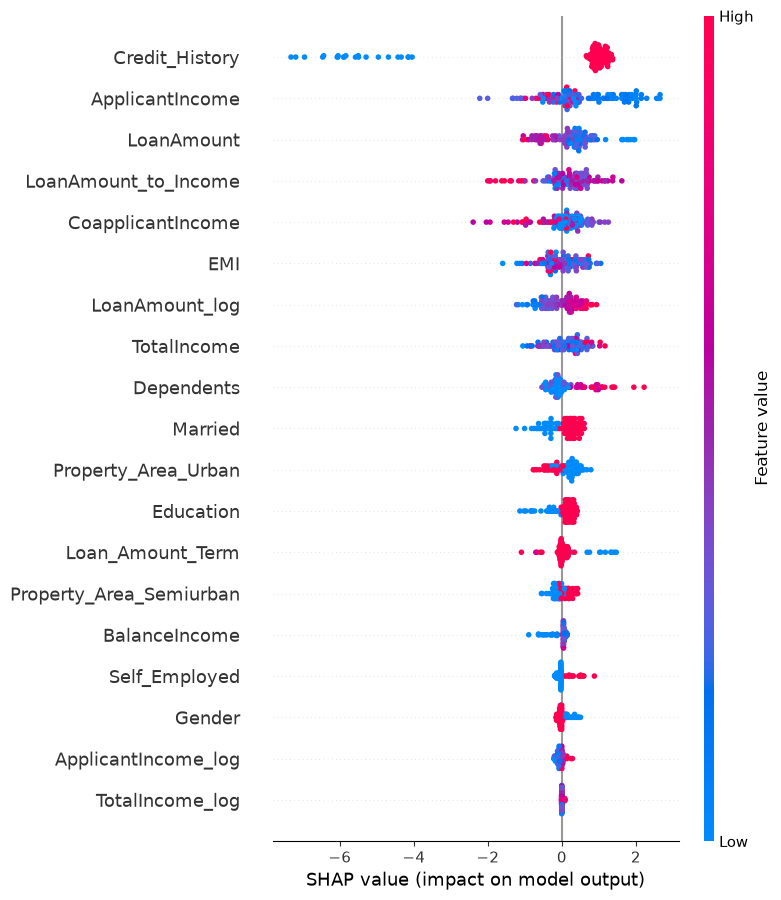

In [24]:
import shap

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, show=False)
plt.savefig('../outputs/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
import joblib
import os

os.makedirs('../models', exist_ok=True)
joblib.dump(xgb, '../models/xgb_v1.pkl')
joblib.dump(scaler, '../models/scaler_v1.pkl')

['../models/scaler_v1.pkl']

In [26]:
import joblib
joblib.dump(rf, '../models/rf_final.pkl')
joblib.dump(scaler, '../models/scaler_v1.pkl')  

['../models/scaler_v1.pkl']